# Structural Analysis of the ENZYMES Dataset

This notebook performs a structural analysis of the ENZYMES dataset similar to the one conducted for the Cora citation network.  

Since ENZYMES contains multiple small graphs rather than a single large graph, structural statistics are computed per graph and then aggregated across the dataset.

These diagnostics help identify potential structural bottlenecks that may affect message passing in Graph Neural Networks.

In [6]:
import sys
import os
import time
import random
import json

import torch
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from torch_geometric.datasets import Planetoid, TUDataset
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.loader import DataLoader

from torch.utils.data import random_split

import networkx as nx

In [2]:
sns.set_style("white")

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": False
})

os.makedirs("figures", exist_ok=True)

## Dataset

The experiments are conducted on the Enzymes dataset

In [3]:
dataset = TUDataset(root="../data", name="ENZYMES")

print(dataset)
print("Number of graphs:", len(dataset))
print("Num node features:", dataset.num_features)
print("Num classes:", dataset.num_classes)

ENZYMES(600)
Number of graphs: 600
Num node features: 3
Num classes: 6


## Models

In [4]:
sys.path.append(os.path.abspath(".."))

from src.models.graph_classification import GCN, GraphSAGE, GAT

from src.training.train import train_enzymes
from src.training.evaluate import evaluate_enzymes

from src.utils.seed import set_seed

## Effect of Model Depth

The experiment evaluates GCN models with varying numbers of layers. The objective is to observe whether increasing the number of message-passing steps leads to improved performance or, alternatively, to performance degradation.

A consistent drop in accuracy for deeper models may indicate the presence of information bottlenecks that limit the effective propagation of signals through the graph.

Running on cuda

Running experiments for GCN


100%|██████████| 800/800 [01:23<00:00,  9.60it/s]


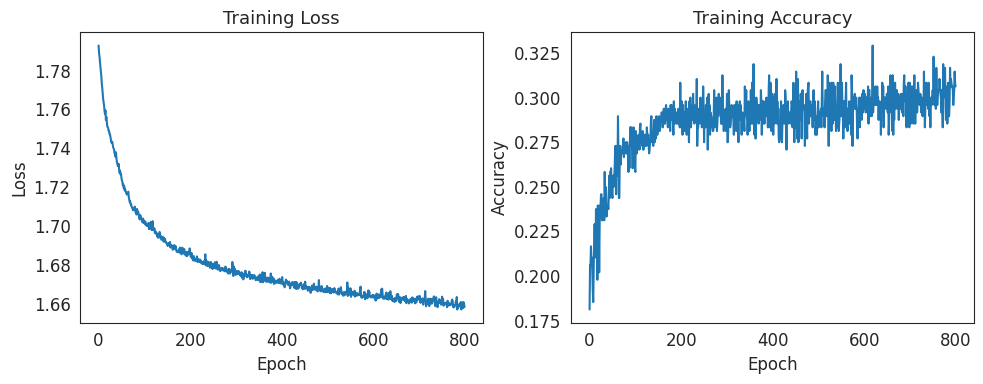

Layers: 2 | Accuracy: 0.2917 ± 0.0053


 78%|███████▊  | 628/800 [01:42<00:28,  6.10it/s]


KeyboardInterrupt: 

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
num_classes = dataset.num_classes

hidden_dim = 64
epochs = 800
lr = 0.001
weight_decay = 0.0005

layer_values = [2, 4] #, 6, 8]
seeds = [0, 1, 2, 3, 4]

results = {m: {"layers": [], "acc_mean": [], "acc_std": [], "time": []} for m in models.keys()}

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


for model_name, Model in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    for num_layers in layer_values:

        acc_runs = []
        time_runs = []

        for seed in seeds:

            set_seed(seed)

            model = Model(in_dim, hidden_dim, num_classes, num_layers).to(device)

            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=lr,
                weight_decay=weight_decay
            )

            start = time.time()

            history = train_enzymes(
                model,
                train_loader,
                optimizer,
                epochs=epochs,
                device=device
            )

            elapsed = time.time() - start

            acc = evaluate_enzymes(
                model,
                test_loader,
                device=device
            )

            acc_runs.append(acc)
            time_runs.append(elapsed)

        plot(history)

        # estadísticas
        acc_mean = np.mean(acc_runs)
        acc_std = np.std(acc_runs)

        results[model_name]["layers"].append(num_layers)
        results[model_name]["acc_mean"].append(acc_mean)
        results[model_name]["acc_std"].append(acc_std)
        results[model_name]["time"].append(np.mean(time_runs))

        print(
            f"Layers: {num_layers} | "
            f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}"
        )

In [12]:
def plot(history):
    epochs = range(len(history["train_loss"]))

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # --- Loss plot ---
    axs[0].plot(epochs, history["train_loss"])
    axs[0].set_title("Training Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")

    # --- Accuracy plot ---
    axs[1].plot(epochs, history["train_acc"])
    axs[1].set_title("Training Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")

    plt.tight_layout()
    plt.show()


In [ ]:
colors = {
    "gcn": "#4C72B0",
    "graphsage": "#55A868",
    "gat": "#C44E52"
}

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})

In [ ]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    plt.plot(
        data["layers"],
        data["acc"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

plt.xlabel("Number of Layers")
plt.ylabel("Test Accuracy")

plt.title("Effect of Depth on GNN Performance (Cora)")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../results/plots/accuracy_vs_layers_cora.png", dpi=300)

plt.show()

In [ ]:
plt.figure(figsize=(6,4))

for model, data in results.items():

    plt.plot(
        data["layers"],
        data["time"],
        marker="o",
        linewidth=2,
        markersize=6,
        color=colors[model],
        label=model.upper()
    )

plt.xlabel("Number of Layers")
plt.ylabel("Training Time (seconds)")

plt.title("Training Time vs Model Depth")

plt.legend(frameon=False)

plt.tight_layout()

plt.savefig("../results/plots/time_vs_layers_cora.png", dpi=300)

plt.show()

In [ ]:
rows = []
for model in results:
    for i in range(len(results[model]["layers"])):
        rows.append({
            "model": model,
            "layers": results[model]["layers"][i],
            "accuracy": results[model]["acc"][i],
            "time": results[model]["time"][i]
        })

df = pd.DataFrame(rows)
df.to_csv("../results/tables/enzymes/gnn_layer_experiments.csv", index=False)

In [ ]:
with open("../results/tables/enzymes/gnn_layer_experiments.json", "w") as f:
    json.dump(results, f, indent=4)

## Graph Structural Properties

Oversquashing is closely related to structural bottlenecks in the graph. Intuitively, if many nodes must communicate through a small number of edges, information from distant parts of the graph becomes compressed as it propagates.

One way to explore this is to analyze how the size of a node's neighborhood grows as the number of hops increases.

In [8]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

print("Average nodes per graph:", np.mean(num_nodes))
print("Average edges per graph:", np.mean(num_edges))

Average nodes per graph: 32.63333333333333
Average edges per graph: 124.27333333333333


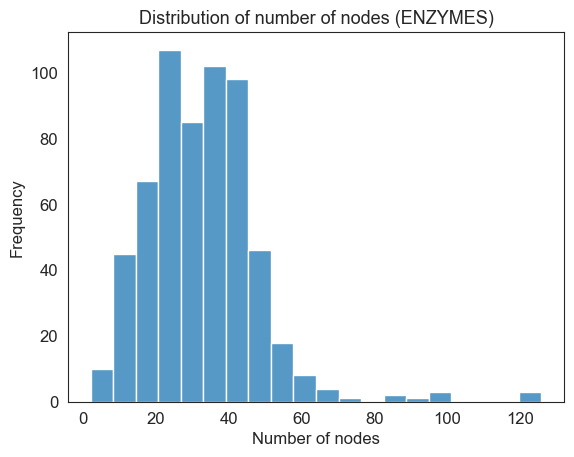

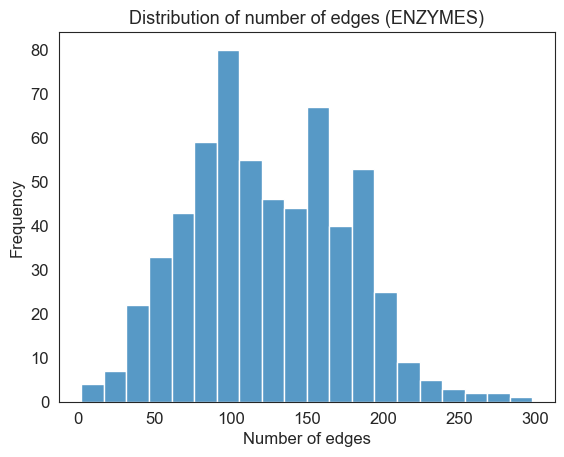

In [24]:
num_nodes = []
num_edges = []

for data in dataset:
    num_nodes.append(data.num_nodes)
    num_edges.append(data.num_edges)

plt.figure()
sns.histplot(num_nodes, bins=20, kde=False)
plt.title("Distribution of number of nodes (ENZYMES)")
plt.xlabel("Number of nodes")
plt.ylabel("Frequency")
plt.savefig(
    "../results/plots/enzymes/distribution_nodes.png",
    dpi=300
)
plt.show()

plt.figure()
sns.histplot(num_edges, bins=20, kde=False)
plt.title("Distribution of number of edges (ENZYMES)")
plt.xlabel("Number of edges")
plt.ylabel("Frequency")
plt.savefig(
    "../results/plots/enzymes/distribution of edges.png",
    dpi=300
)
plt.show()

In [11]:
nx_graphs = []

for data in dataset:
    G = to_networkx(data, to_undirected=True)
    nx_graphs.append(G)

print("Converted graphs:", len(nx_graphs))

Converted graphs: 600


In [15]:
betweenness_values = []

for G in nx_graphs:
    if G.number_of_edges() == 0:
        continue
        
    edge_bet = nx.edge_betweenness_centrality(G)
    betweenness_values.extend(edge_bet.values())

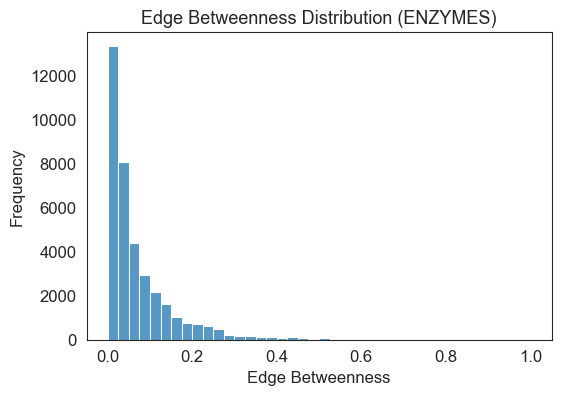

In [25]:
plt.figure(figsize=(6,4))

sns.histplot(betweenness_values, bins=40)

plt.xlabel("Edge Betweenness")
plt.ylabel("Frequency")
plt.title("Edge Betweenness Distribution (ENZYMES)")
plt.savefig(
    "../results/plots/enzymes/edge_betweenness.png",
    dpi=300
)

plt.show()

In [18]:
top_values = sorted(betweenness_values)[-50:]
top_values = np.sort(top_values)

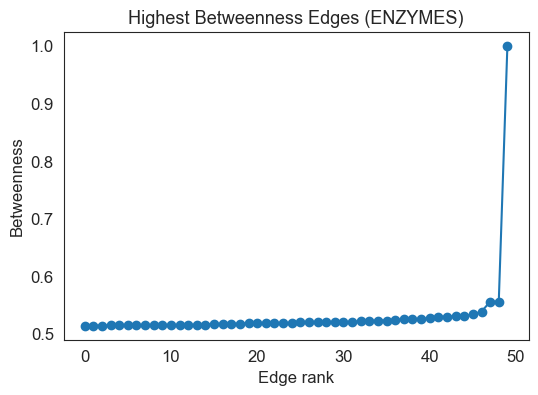

In [29]:
plt.figure(figsize=(6,4))

plt.plot(top_values, marker='o')

plt.xlabel("Edge rank")
plt.ylabel("Betweenness")
plt.title("Highest Betweenness Edges (ENZYMES)")
plt.savefig(
    "../results/plots/enzymes/highest_betweenness_edges_enzymes.png",
    dpi=300
)
plt.show()

In [30]:
def average_khop_growth(graphs, max_k=5):

    growth = []

    for k in range(1, max_k+1):

        sizes = []

        for G in graphs:

            if len(G.nodes()) == 0:
                continue

            node = list(G.nodes())[0]

            nodes = nx.single_source_shortest_path_length(G, node, cutoff=k)

            sizes.append(len(nodes))

        growth.append(np.mean(sizes))

    return growth

In [31]:
khop_growth = average_khop_growth(nx_graphs)

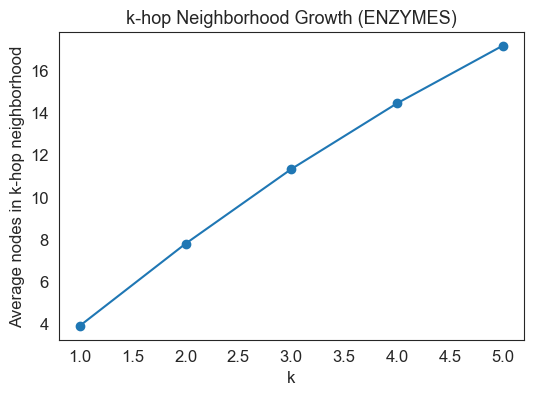

In [32]:
plt.figure(figsize=(6,4))

plt.plot(range(1,6), khop_growth, marker='o')

plt.xlabel("k")
plt.ylabel("Average nodes in k-hop neighborhood")
plt.title("k-hop Neighborhood Growth (ENZYMES)")
plt.savefig(
    "../results/plots/enzymes/average_nodes_in_khop.png",
    dpi=300
)
plt.show()

## Baseline GNN Performance on ENZYMES

In this section we evaluate how model depth affects performance and computational cost
on the ENZYMES dataset.

We train baseline GNN architectures with different numbers of layers and measure:

- test accuracy
- training time

These experiments help identify whether increasing depth introduces optimization
difficulties or structural limitations related to message passing.

In [11]:
from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

models = {
    "gcn": GCN,
    "graphsage": GraphSAGE,
    "gat": GAT
}

in_dim = dataset.num_features
num_classes = dataset.num_classes

hidden_dim = 64
epochs = 200
lr = 0.005
weight_decay = 0.0005

layer_values = [2, 3, 4, 6, 8]

results = {m: {"layers": [], "acc": [], "time": []} for m in models.keys()}

train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)


for model_name, Model in models.items():

    print(f"\nRunning experiments for {model_name.upper()}")

    for layers in layer_values:

        model = Model(in_dim, hidden_dim, num_classes, layers).to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

        start = time.time()

        history = train_enzymes(
            model,
            train_loader,
            optimizer,
            epochs=epochs,
            device=device
        )

        elapsed = time.time() - start

        acc = evaluate_enzymes(
            model,
            test_loader,
            device=device
        )

        results[model_name]["layers"].append(layers)
        results[model_name]["acc"].append(acc)
        results[model_name]["time"].append(elapsed)

        print(
            f"{model_name} | layers={layers} | acc={acc:.3f} | time={elapsed:.1f}s"
        )


Running experiments for GCN


  0%|          | 0/200 [00:00<?, ?it/s]


TypeError: GCN.forward() takes 3 positional arguments but 4 were given